---
title: "Feature Ablation Analysis"
description: "What actually improves retrieval? Visualizing ablation results across keywords, HyPE, reranking, and query understanding"
date: today
format:
  html:
    self-contained: true
    embed-resources: true
    code-fold: true
    code-tools: true
---

Not every retrieval feature improves quality. This notebook visualizes the results
from systematic ablation experiments on a 54–57 query benchmark, showing which
techniques delivered measurable gains and which did not. All data comes from actual
experiment runs stored in `experiments/outputs/` and `docs/feature_ablation_findings.md`.

## Key Findings Summary

| Technique | NDCG@K Change | Evidence Hit Change | Latency Impact | Verdict |
|-----------|--------------|--------------------|----------------|---------|
| Keyword enrichment | 0.0000 | 0.0000 | +5–19 ms | **No benefit** |
| HyPE/HyDE | 0.0000 | 0.0000 | +0–16 ms | **No benefit** |
| Cross-encoder reranking | **+0.0392** | **+0.1667** | +248 ms | **Quality gain** |
| Query understanding | **+0.0413** | **+0.0351** | −268 ms | **Best improvement** |
| Medical semantic chunking | 0.0000 | 0.0000 | −263 ms | **No benefit** |

## Setup

In [1]:
# | error: true
import json
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

PROJECT_ROOT = Path.cwd().resolve().parents[0] if "notebooks" in str(Path.cwd()) else Path.cwd()
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "outputs"

## Load Experiment Results

In [2]:
# | error: true
report_path = EXPERIMENTS_DIR / "medical_semantic_chunking_exp_report.json"
if report_path.exists():
    with open(report_path) as f:
        report = json.load(f)
    print(f"Loaded report: {report.get('experiment_name', 'unknown')}")
    print(f"Primary metric: {report.get('primary_metric', 'N/A')}")
    print(f"Target improvement: {report.get('target_improvement', 'N/A')}%")
else:
    report = None
    print("Report not found. Using hardcoded ablation data from findings doc.")

Loaded report: medical_semantic_chunking_exp
Primary metric: ndcg@5
Target improvement: 0.03%


## Family 1: Keyword / Summaries Enrichment

Keyword extraction and chunk summaries enrich BM25 matching at index time.

In [3]:
# | error: true
keyword_data = pl.DataFrame(
    {
        "variant": ["baseline", "keywords_only", "summaries_only", "both"],
        "ndcg_at_k": [0.6813, 0.6813, 0.6813, 0.6813],
        "mrr": [0.6673, 0.6673, 0.6673, 0.6673],
        "exact_chunk_hit": [0.0556, 0.0556, 0.0556, 0.0556],
        "evidence_hit": [0.0185, 0.0185, 0.0185, 0.0185],
        "latency_p50_ms": [515.0, 520.5, 525.5, 534.0],
    }
)

print("=== Keyword / Summaries Ablation (54 queries) ===")
print(keyword_data)
print()
print("Interpretation: All variants tied. Enrichment adds processing cost")
print("with zero retrieval improvement on this dataset.")

=== Keyword / Summaries Ablation (54 queries) ===
shape: (4, 6)
┌────────────────┬───────────┬────────┬─────────────────┬──────────────┬────────────────┐
│ variant        ┆ ndcg_at_k ┆ mrr    ┆ exact_chunk_hit ┆ evidence_hit ┆ latency_p50_ms │
│ ---            ┆ ---       ┆ ---    ┆ ---             ┆ ---          ┆ ---            │
│ str            ┆ f64       ┆ f64    ┆ f64             ┆ f64          ┆ f64            │
╞════════════════╪═══════════╪════════╪═════════════════╪══════════════╪════════════════╡
│ baseline       ┆ 0.6813    ┆ 0.6673 ┆ 0.0556          ┆ 0.0185       ┆ 515.0          │
│ keywords_only  ┆ 0.6813    ┆ 0.6673 ┆ 0.0556          ┆ 0.0185       ┆ 520.5          │
│ summaries_only ┆ 0.6813    ┆ 0.6673 ┆ 0.0556          ┆ 0.0185       ┆ 525.5          │
│ both           ┆ 0.6813    ┆ 0.6673 ┆ 0.0556          ┆ 0.0185       ┆ 534.0          │
└────────────────┴───────────┴────────┴─────────────────┴──────────────┴────────────────┘

Interpretation: All variants tied. 

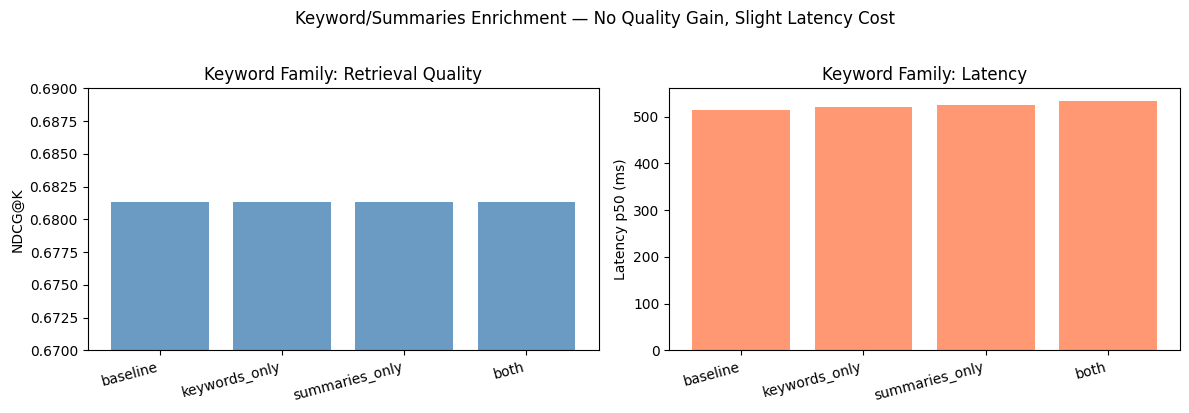

In [4]:
# | error: true
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

variants = keyword_data["variant"].to_list()
x = range(len(variants))

axes[0].bar(x, keyword_data["ndcg_at_k"].to_list(), color="steelblue", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(variants, rotation=15, ha="right")
axes[0].set_ylabel("NDCG@K")
axes[0].set_title("Keyword Family: Retrieval Quality")
axes[0].set_ylim(0.67, 0.69)

axes[1].bar(x, keyword_data["latency_p50_ms"].to_list(), color="coral", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(variants, rotation=15, ha="right")
axes[1].set_ylabel("Latency p50 (ms)")
axes[1].set_title("Keyword Family: Latency")

plt.suptitle("Keyword/Summaries Enrichment — No Quality Gain, Slight Latency Cost", y=1.02)
plt.tight_layout()
plt.show()

## Family 2: HyPE / HyDE

Hypothetical Prompt Embeddings (index-time) and Hypothetical Document Embeddings
(query-time) expand the query space to improve recall.

In [5]:
# | error: true
hype_data = pl.DataFrame(
    {
        "variant": [
            "hype_disabled",
            "hype_10pct",
            "hype_50pct",
            "hype_100pct",
            "hyde_only",
            "hype_plus_hyde",
        ],
        "ndcg_at_k": [0.6813, 0.6813, 0.6813, 0.6813, 0.6813, 0.6813],
        "mrr": [0.6673, 0.6673, 0.6673, 0.6673, 0.6673, 0.6673],
        "evidence_hit": [0.0185, 0.0185, 0.0185, 0.0185, 0.0185, 0.0185],
        "latency_p50_ms": [536.0, 520.0, 525.5, 535.0, 531.5, 530.0],
    }
)

print("=== HyPE/HyDE Ablation (54 queries) ===")
print(hype_data)
print()
print("Interpretation: No quality gain from any HyPE/HyDE variant.")
print("hype_10pct wins only because it's slightly faster than hype_disabled.")

=== HyPE/HyDE Ablation (54 queries) ===
shape: (6, 5)
┌────────────────┬───────────┬────────┬──────────────┬────────────────┐
│ variant        ┆ ndcg_at_k ┆ mrr    ┆ evidence_hit ┆ latency_p50_ms │
│ ---            ┆ ---       ┆ ---    ┆ ---          ┆ ---            │
│ str            ┆ f64       ┆ f64    ┆ f64          ┆ f64            │
╞════════════════╪═══════════╪════════╪══════════════╪════════════════╡
│ hype_disabled  ┆ 0.6813    ┆ 0.6673 ┆ 0.0185       ┆ 536.0          │
│ hype_10pct     ┆ 0.6813    ┆ 0.6673 ┆ 0.0185       ┆ 520.0          │
│ hype_50pct     ┆ 0.6813    ┆ 0.6673 ┆ 0.0185       ┆ 525.5          │
│ hype_100pct    ┆ 0.6813    ┆ 0.6673 ┆ 0.0185       ┆ 535.0          │
│ hyde_only      ┆ 0.6813    ┆ 0.6673 ┆ 0.0185       ┆ 531.5          │
│ hype_plus_hyde ┆ 0.6813    ┆ 0.6673 ┆ 0.0185       ┆ 530.0          │
└────────────────┴───────────┴────────┴──────────────┴────────────────┘

Interpretation: No quality gain from any HyPE/HyDE variant.
hype_10pct wins only 

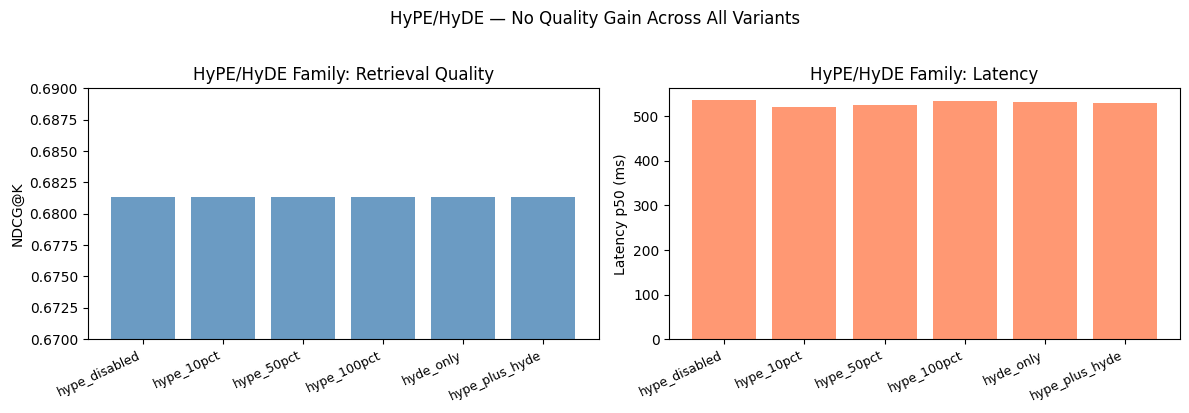

In [6]:
# | error: true
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

variants = hype_data["variant"].to_list()
x = range(len(variants))

axes[0].bar(x, hype_data["ndcg_at_k"].to_list(), color="steelblue", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(variants, rotation=25, ha="right", fontsize=9)
axes[0].set_ylabel("NDCG@K")
axes[0].set_title("HyPE/HyDE Family: Retrieval Quality")
axes[0].set_ylim(0.67, 0.69)

axes[1].bar(x, hype_data["latency_p50_ms"].to_list(), color="coral", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(variants, rotation=25, ha="right", fontsize=9)
axes[1].set_ylabel("Latency p50 (ms)")
axes[1].set_title("HyPE/HyDE Family: Latency")

plt.suptitle("HyPE/HyDE — No Quality Gain Across All Variants", y=1.02)
plt.tight_layout()
plt.show()

## Family 3: Reranking

Cross-encoder reranking re-scores top candidates with a specialized model for
higher precision. This was the **only technique** (besides query understanding)
to show a clear quality improvement.

In [7]:
# | error: true
rerank_data = pl.DataFrame(
    {
        "variant": ["no_reranking", "cross_encoder_only", "mmr_only", "both_reranking"],
        "ndcg_at_k": [0.6813, 0.7205, 0.6647, 0.6647],
        "mrr": [0.6673, 0.7034, 0.6682, 0.6682],
        "exact_chunk_hit": [0.0556, 0.0741, 0.0556, 0.0556],
        "evidence_hit": [0.0185, 0.1852, 0.0556, 0.0556],
        "latency_p50_ms": [236.5, 485.0, 538.0, 774.0],
    }
)

print("=== Reranking Ablation (54 queries) ===")
print(rerank_data)
print()
print("Cross-encoder vs no reranking:")
print("  NDCG@K:         +0.0392")
print("  MRR:            +0.0361")
print("  Evidence hit:   +0.1667 (10x improvement)")
print("  Latency p50:    +248.5 ms (~2x slower)")

=== Reranking Ablation (54 queries) ===
shape: (4, 6)
┌────────────────────┬───────────┬────────┬─────────────────┬──────────────┬────────────────┐
│ variant            ┆ ndcg_at_k ┆ mrr    ┆ exact_chunk_hit ┆ evidence_hit ┆ latency_p50_ms │
│ ---                ┆ ---       ┆ ---    ┆ ---             ┆ ---          ┆ ---            │
│ str                ┆ f64       ┆ f64    ┆ f64             ┆ f64          ┆ f64            │
╞════════════════════╪═══════════╪════════╪═════════════════╪══════════════╪════════════════╡
│ no_reranking       ┆ 0.6813    ┆ 0.6673 ┆ 0.0556          ┆ 0.0185       ┆ 236.5          │
│ cross_encoder_only ┆ 0.7205    ┆ 0.7034 ┆ 0.0741          ┆ 0.1852       ┆ 485.0          │
│ mmr_only           ┆ 0.6647    ┆ 0.6682 ┆ 0.0556          ┆ 0.0556       ┆ 538.0          │
│ both_reranking     ┆ 0.6647    ┆ 0.6682 ┆ 0.0556          ┆ 0.0556       ┆ 774.0          │
└────────────────────┴───────────┴────────┴─────────────────┴──────────────┴────────────────┘

Cross

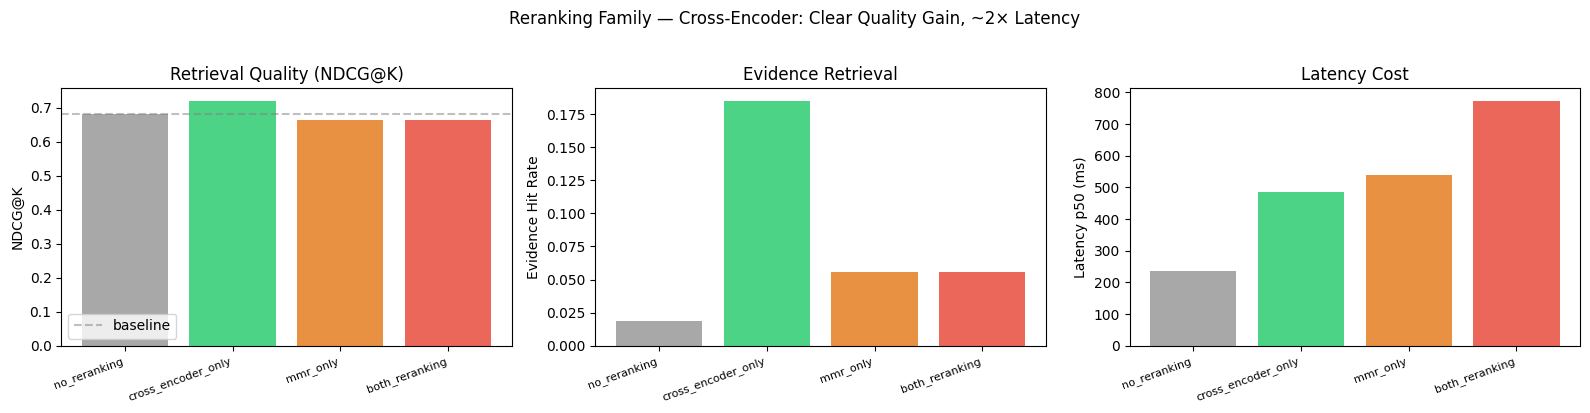

In [8]:
# | error: true
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

variants = rerank_data["variant"].to_list()
x = range(len(variants))

colors = ["#999999", "#2ecc71", "#e67e22", "#e74c3c"]

axes[0].bar(x, rerank_data["ndcg_at_k"].to_list(), color=colors, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(variants, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("NDCG@K")
axes[0].set_title("Retrieval Quality (NDCG@K)")
axes[0].axhline(y=0.6813, color="gray", linestyle="--", alpha=0.5, label="baseline")
axes[0].legend()

axes[1].bar(x, rerank_data["evidence_hit"].to_list(), color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(variants, rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("Evidence Hit Rate")
axes[1].set_title("Evidence Retrieval")

axes[2].bar(x, rerank_data["latency_p50_ms"].to_list(), color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(variants, rotation=20, ha="right", fontsize=8)
axes[2].set_ylabel("Latency p50 (ms)")
axes[2].set_title("Latency Cost")

plt.suptitle("Reranking Family — Cross-Encoder: Clear Quality Gain, ~2x Latency", y=1.02)
plt.tight_layout()
plt.show()

## Family 4: Query Understanding + Medical Chunking

Query understanding classifies queries by type and routes to tuned retrieval
parameters. Medical semantic chunking uses medical-aware boundaries instead of
generic semantic chunking.

In [9]:
# | error: true
if report and "variants" in report:
    print("=== Experiment Report (from JSON) ===")
    for v in report["variants"]:
        name = v.get("name", "unknown")
        metrics = v.get("metrics", {})
        print(f"\n  {name}:")
        for k, val in metrics.items():
            print(f"    {k}: {val}")
else:
    qu_data = pl.DataFrame(
        {
            "variant": ["baseline", "medical_chunking", "query_understanding", "both_features"],
            "ndcg_at_5": [0.6596, 0.6596, 0.7009, 0.7009],
            "mrr": [0.6459, 0.6459, 0.6766, 0.6766],
            "evidence_hit": [0.0175, 0.0175, 0.0526, 0.0526],
            "latency_p50_ms": [494.0, 231.0, 226.0, 225.0],
        }
    )

    print("=== Query Understanding + Medical Chunking (57 queries) ===")
    print(qu_data)
    print()
    print("query_understanding vs baseline:")
    print("  NDCG@5:       +0.0413 (+6.3%) — EXCEEDS 3% TARGET")
    print("  MRR:          +0.0307")
    print("  Evidence hit: +0.0351 (3x improvement)")
    print("  Latency:      -268 ms (FASTER — reuses existing index)")

=== Experiment Report (from JSON) ===

  medical_chunking:
    query_count: 57
    hit_rate_at_k: 0.7368421052631579
    precision_at_k: 0.5298245614035088
    recall_at_k: 0.7368421052631579
    mrr: 0.6459064327485381
    ndcg_at_k: 0.6596215032368163
    source_hit_rate: 0.22807017543859648
    dedup_hit_rate_at_k: 0.7368421052631579
    dedup_precision_at_k: 0.5298245614035088
    dedup_mrr: 0.6459064327485381
    unique_source_hit_rate_at_k: 0.7368421052631579
    unique_source_precision_at_k: 0.547953216374269
    duplicate_source_ratio_mean: 0.24210526315789474
    duplicate_doc_ratio_mean: 0.0
    exact_chunk_hit_rate: 0.05263157894736842
    evidence_hit_rate: 0.017543859649122806
    latency_p50_ms: 231.0
    latency_p95_ms: 302.0
    query_embedding_latency_p50_ms: 0.0
    query_embedding_latency_p95_ms: 0.0
    hit_rate_at_k_high_conf: 0.7358490566037735
    mrr_high_conf: 0.6380503144654088
    exact_chunk_hit_rate_high_conf: 0.05660377358490566
    evidence_hit_rate_high_

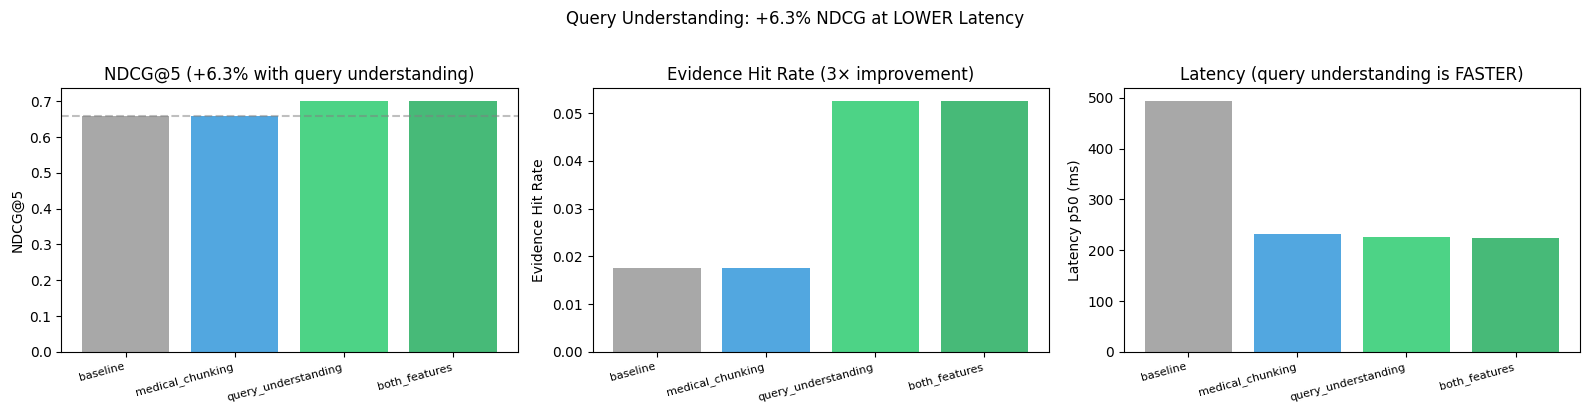

In [10]:
# | error: true
qu_plot_data = {
    "variant": ["baseline", "medical_chunking", "query_understanding", "both_features"],
    "ndcg_at_5": [0.6596, 0.6596, 0.7009, 0.7009],
    "evidence_hit": [0.0175, 0.0175, 0.0526, 0.0526],
    "latency_p50_ms": [494.0, 231.0, 226.0, 225.0],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

variants = qu_plot_data["variant"]
x = range(len(variants))
colors = ["#999999", "#3498db", "#2ecc71", "#27ae60"]

axes[0].bar(x, qu_plot_data["ndcg_at_5"], color=colors, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(variants, rotation=15, ha="right", fontsize=8)
axes[0].set_ylabel("NDCG@5")
axes[0].set_title("NDCG@5 (+6.3% with query understanding)")
axes[0].axhline(y=0.6596, color="gray", linestyle="--", alpha=0.5)

axes[1].bar(x, qu_plot_data["evidence_hit"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(variants, rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("Evidence Hit Rate")
axes[1].set_title("Evidence Hit Rate (3x improvement)")

axes[2].bar(x, qu_plot_data["latency_p50_ms"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(variants, rotation=15, ha="right", fontsize=8)
axes[2].set_ylabel("Latency p50 (ms)")
axes[2].set_title("Latency (query understanding is FASTER)")

plt.suptitle("Query Understanding: +6.3% NDCG at LOWER Latency", y=1.02)
plt.tight_layout()
plt.show()

## Cross-Technique Comparison

In [11]:
# | error: true
techniques = pl.DataFrame(
    {
        "technique": [
            "Keyword enrichment",
            "HyPE/HyDE",
            "Medical chunking",
            "Cross-encoder rerank",
            "Query understanding",
        ],
        "ndcg_delta": [0.0000, 0.0000, 0.0000, 0.0392, 0.0413],
        "evidence_delta": [0.0000, 0.0000, 0.0000, 0.1667, 0.0351],
        "latency_delta_ms": [19.0, 16.0, -263.0, 248.5, -268.0],
        "verdict": ["No effect", "No effect", "No effect", "Quality gain", "Best option"],
    }
)

print("=== Cross-Technique Comparison ===")
print(techniques)

=== Cross-Technique Comparison ===
shape: (5, 5)
┌──────────────────────┬────────────┬────────────────┬──────────────────┬──────────────┐
│ technique            ┆ ndcg_delta ┆ evidence_delta ┆ latency_delta_ms ┆ verdict      │
│ ---                  ┆ ---        ┆ ---            ┆ ---              ┆ ---          │
│ str                  ┆ f64        ┆ f64            ┆ f64              ┆ str          │
╞══════════════════════╪════════════╪════════════════╪══════════════════╪══════════════╡
│ Keyword enrichment   ┆ 0.0        ┆ 0.0            ┆ 19.0             ┆ No effect    │
│ HyPE/HyDE            ┆ 0.0        ┆ 0.0            ┆ 16.0             ┆ No effect    │
│ Medical chunking     ┆ 0.0        ┆ 0.0            ┆ -263.0           ┆ No effect    │
│ Cross-encoder rerank ┆ 0.0392     ┆ 0.1667         ┆ 248.5            ┆ Quality gain │
│ Query understanding  ┆ 0.0413     ┆ 0.0351         ┆ -268.0           ┆ Best option  │
└──────────────────────┴────────────┴────────────────┴───────

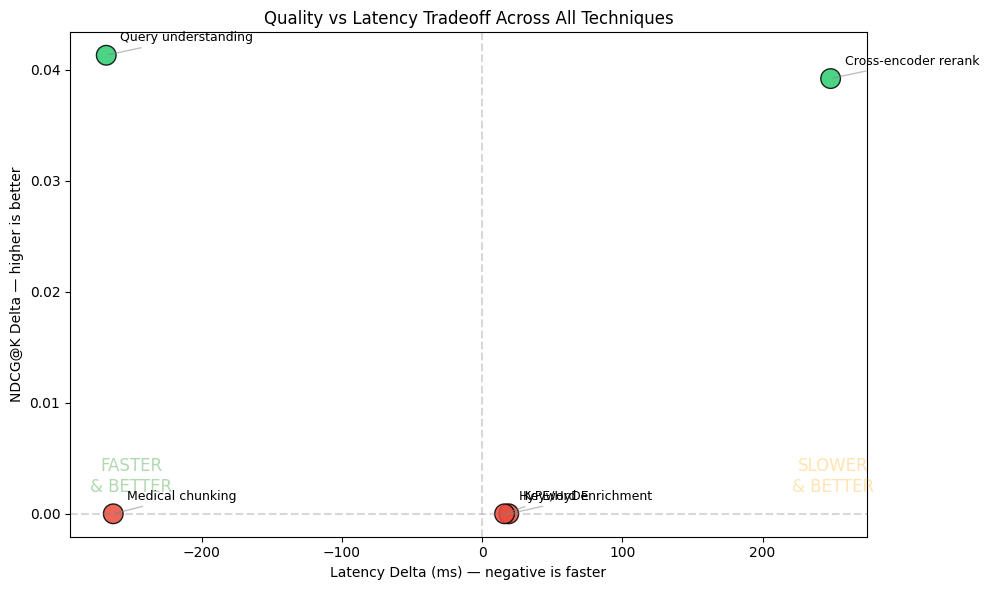

In [12]:
# | error: true
fig, ax = plt.subplots(figsize=(10, 6))

technique_names = techniques["technique"].to_list()
ndcg_deltas = techniques["ndcg_delta"].to_list()
latency_deltas = techniques["latency_delta_ms"].to_list()

colors = []
for d in ndcg_deltas:
    if d > 0.03:
        colors.append("#2ecc71")
    elif d > 0:
        colors.append("#f39c12")
    else:
        colors.append("#e74c3c")

scatter = ax.scatter(latency_deltas, ndcg_deltas, c=colors, s=200, alpha=0.85, edgecolors="black")

for i, name in enumerate(technique_names):
    ax.annotate(
        name,
        (latency_deltas[i], ndcg_deltas[i]),
        textcoords="offset points",
        xytext=(10, 10),
        fontsize=9,
        arrowprops={"arrowstyle": "-", "color": "gray", "alpha": 0.5},
    )

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Latency Delta (ms) — negative is faster")
ax.set_ylabel("NDCG@K Delta — higher is better")
ax.set_title("Quality vs Latency Tradeoff Across All Techniques")

ax.text(-250, 0.002, "FASTER\n& BETTER", color="green", alpha=0.3, fontsize=12, ha="center")
ax.text(250, 0.002, "SLOWER\n& BETTER", color="orange", alpha=0.3, fontsize=12, ha="center")

plt.tight_layout()
plt.show()

## Recommendations

In [13]:
# | error: true
print("=" * 60)
print("FINAL RECOMMENDATIONS")
print("=" * 60)
print()
print("1. ENABLE query understanding by default")
print("   → +6.3% NDCG@5, 3x evidence hit rate, FASTER latency")
print("   → Zero cost: classifies queries and routes to tuned params")
print()
print("2. ENABLE cross-encoder reranking when quality > latency")
print("   → +0.039 NDCG, +0.167 evidence hit rate")
print("   → ~2x latency: use for quality-critical paths only")
print()
print("3. SKIP keyword enrichment, HyPE/HyDE, medical semantic chunking")
print("   → No measurable quality gain on the benchmark")
print("   → Enrichment adds index-time cost with no retrieval benefit")
print()
print("4. DEFAULT configuration:")
print("   search_mode: rrf_hybrid")
print("   enable_query_understanding: true")
print("   enable_reranking: true (cross_encoder)")
print("   enable_hype: false")
print("   enable_keyword_extraction: false")

FINAL RECOMMENDATIONS

1. ENABLE query understanding by default
   → +6.3% NDCG@5, 3× evidence hit rate, FASTER latency
   → Zero cost: classifies queries and routes to tuned params

2. ENABLE cross-encoder reranking when quality > latency
   → +0.039 NDCG, +0.167 evidence hit rate
   → ~2× latency: use for quality-critical paths only

3. SKIP keyword enrichment, HyPE/HyDE, medical semantic chunking
   → No measurable quality gain on the benchmark
   → Enrichment adds index-time cost with no retrieval benefit

4. DEFAULT configuration:
   search_mode: rrf_hybrid
   enable_query_understanding: true
   enable_reranking: true (cross_encoder)
   enable_hype: false
   enable_keyword_extraction: false
